In [19]:
!pip install plotly

                                              0.0/9.9 MB ? eta -:--:--
                                              0.2/9.9 MB 5.3 MB/s eta 0:00:02
     --                                       0.7/9.9 MB 8.8 MB/s eta 0:00:02
     -------                                  1.9/9.9 MB 17.3 MB/s eta 0:00:01
     ------------                             3.2/9.9 MB 18.6 MB/s eta 0:00:01
     ---------------                          3.8/9.9 MB 20.1 MB/s eta 0:00:01
     -----------------                        4.3/9.9 MB 16.2 MB/s eta 0:00:01
     --------------------                     5.0/9.9 MB 16.0 MB/s eta 0:00:01
     ------------------------                 6.0/9.9 MB 17.4 MB/s eta 0:00:01
     ---------------------------              6.7/9.9 MB 16.5 MB/s eta 0:00:01
     -------------------------------          7.9/9.9 MB 17.4 MB/s eta 0:00:01
     --------------------------------------   9.4/9.9 MB 18.9 MB/s eta 0:00:01
     ---------------------------------------  9.9/9.9 MB 19.2 


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import plotly.express as px
import plotly.graph_objects as go

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [22]:
data = pd.read_csv("user_data.csv")

In [65]:
data.head()

,user_id,stage,conversion
0,user_0,homepage,True
1,user_1,homepage,True
2,user_2,homepage,True
3,user_3,homepage,True
4,user_4,homepage,True


In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17175 entries, 0 to 17174
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     17175 non-null  object
 1   stage       17175 non-null  object
 2   conversion  17175 non-null  bool  
dtypes: bool(1), object(2)
memory usage: 285.3+ KB


In [67]:
data.describe()

,user_id,stage,conversion
count,17175,17175,17175
unique,17175,5,2
top,user_17174,homepage,True
freq,1,10000,13014


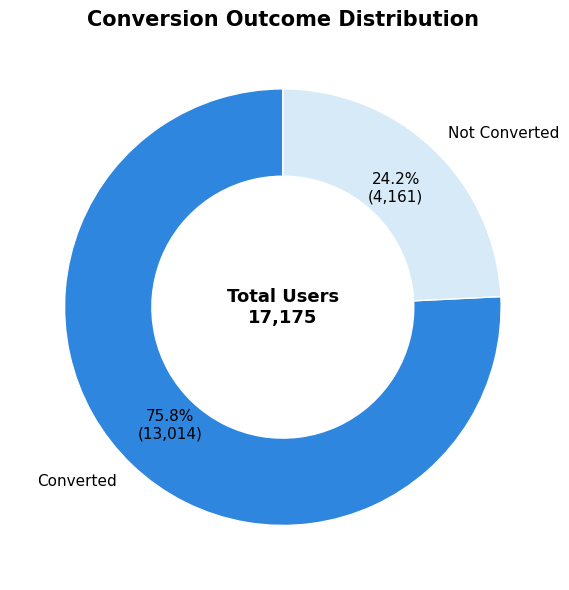

In [88]:
import matplotlib.pyplot as plt

# Count conversion values
conversion = data['conversion'].value_counts()

# Rename labels if needed
label_map = {1: 'Converted', 0: 'Not Converted', 'Да': 'Converted', 'Нет': 'Not Converted'}
labels = [label_map.get(i, str(i)) for i in conversion.index]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    conversion.values,
    labels=labels,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p/100 * conversion.sum())):,})',
    startangle=90,
    colors=['#2E86DE', '#D6EAF8'],
    wedgeprops={'width': 0.4, 'edgecolor': 'white'},
    pctdistance=0.75,
    textprops={'fontsize': 11}
)

# Center text
ax.text(0, 0, f"Total Users\n{conversion.sum():,}",
        ha='center', va='center', fontsize=13, fontweight='bold')

plt.title('Conversion Outcome Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Out of 17,175 total users, 13,014 (75.8%) completed the target action, while 4,161 (24.2%) did not convert.
Although overall conversion appears strong, analyzing the funnel stages is necessary to identify where users drop off during the journey.

In [74]:
stage_order = ['homepage', 'product_page', 'cart', 'checkout', 'purchase']

funnel_df = (
    data.groupby('stage')['user_id']
    .nunique()
    .reindex(stage_order)
    .reset_index(name='users')
)

In [75]:
funnel_df['previous_stage_users'] = funnel_df['users'].shift(1)

funnel_df['stage_conversion_rate'] = (
    funnel_df['users'] / funnel_df['previous_stage_users'] * 100
)

funnel_df.loc[0, 'stage_conversion_rate'] = 100

In [76]:
fig = go.Figure(go.Funnel(
    y=funnel_df['stage'],
    x=funnel_df['users'],
    textinfo="value+percent previous",
    marker={"color": ["#2E86DE", "#48C9B0", "#F5B041", "#AF7AC5", "#EC7063"]}
))

fig.update_layout(
    title="User Conversion Funnel",
    title_x=0.5,
    template="simple_white",
    width=900,
    height=500
)

fig.show()

The largest loss occurs early in the funnel between homepage and product page, suggesting opportunities to improve product discovery or landing page engagement.

In [78]:
from plotly import graph_objects as go

fig = go.Figure(
    go.Funnelarea(
        labels=conversion['stage'],
        values=conversion['user_id'],
        textfont_size=40,
        title='Website user conversion'
    )
)

fig.show()

Out of 17,175 users entering the funnel, 10,000 (58.2%) visit the homepage, but only 225 users (1.3%) complete the purchase, indicating significant drop-off throughout the user journey.


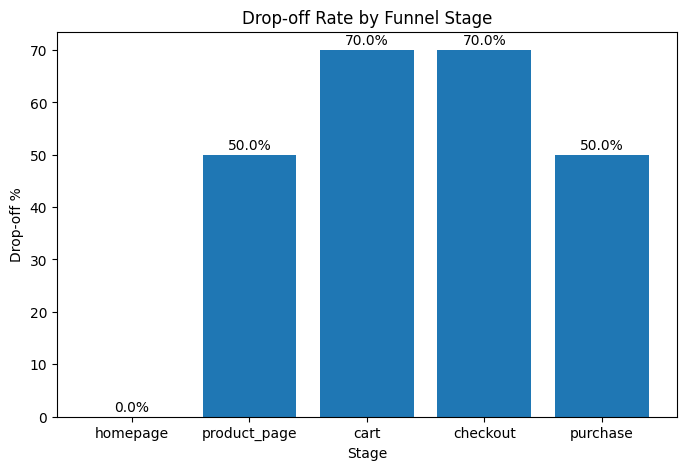

In [77]:
dropoff_df = funnel_df.copy()

dropoff_df['dropoff_rate'] = 100 - dropoff_df['stage_conversion_rate']
dropoff_df.loc[0, 'dropoff_rate'] = 0

plt.figure(figsize=(8,5))
plt.bar(dropoff_df['stage'], dropoff_df['dropoff_rate'])

plt.title("Drop-off Rate by Funnel Stage")
plt.ylabel("Drop-off %")
plt.xlabel("Stage")

for i, v in enumerate(dropoff_df['dropoff_rate']):
    plt.text(i, v+1, f"{v:.1f}%", ha='center')

plt.show()

The largest drop-off occurs between product_page and cart, where nearly 70% of users exit the funnel. This suggests friction in the product exploration or purchase decision stage.